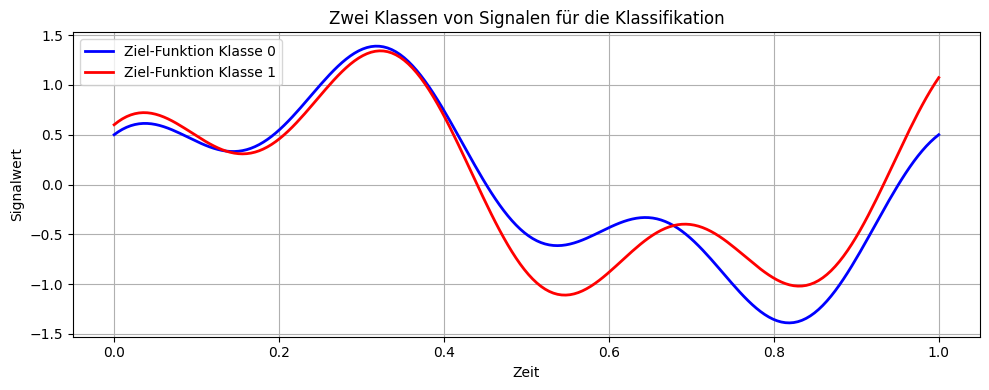

--- Starte Training ---
Epoch 10, Loss: 0.3745
Epoch 20, Loss: 0.0013
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000

Testgenauigkeit: 1.0000


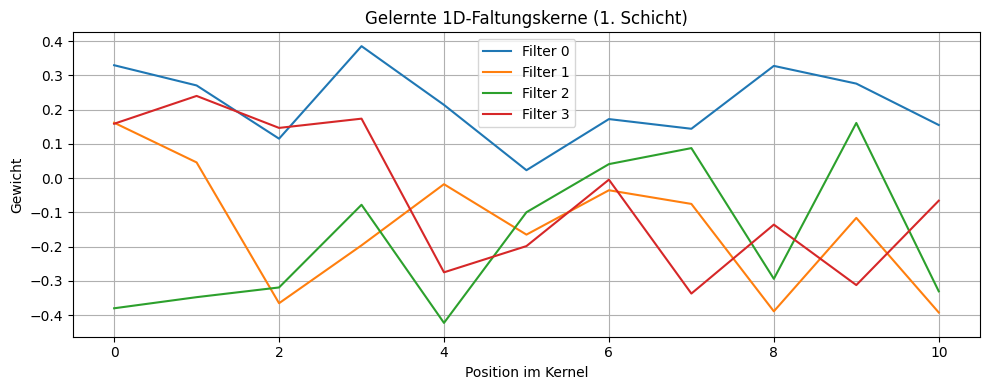

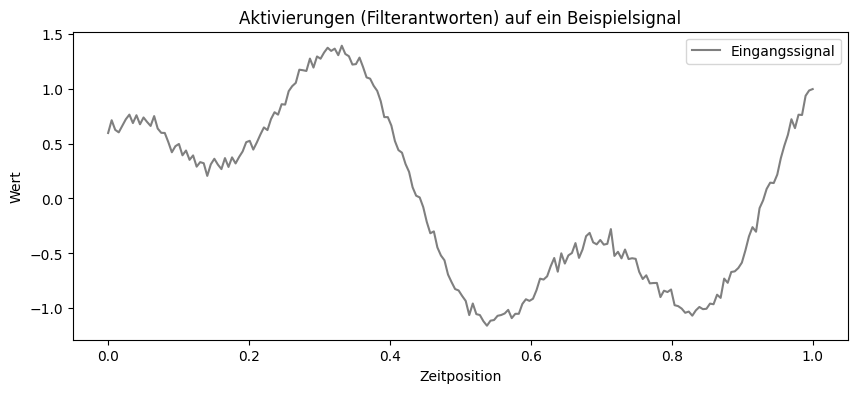

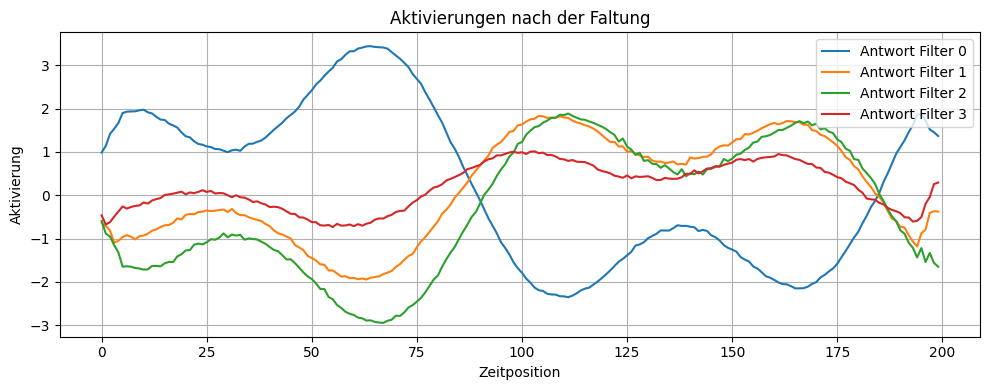

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Ziel-Funktionen für zwei Klassen ---
def base_function_class_0(x):
    """Original-Funktion für Klasse 0"""
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(6 * np.pi * x)

def base_function_class_1(x):
    """Leicht modifizierte Funktion für Klasse 1 (andere Frequenz/Phase)"""
    return np.sin(2.2 * np.pi * x) + 0.6 * np.cos(5.8 * np.pi * x)

# --- Trainingsdatensatz: Erzeugt Daten für zwei Klassen ---
def generate_dataset(n_samples_per_class=50, seq_len=200):
    x_axis = np.linspace(0, 1, seq_len)
    X = []
    y = []

    # Klasse 0
    for _ in range(n_samples_per_class):
        signal = base_function_class_0(x_axis) + 0.05 * np.random.randn(seq_len)
        X.append(signal)
        y.append(0)

    # Klasse 1
    for _ in range(n_samples_per_class):
        signal = base_function_class_1(x_axis) + 0.05 * np.random.randn(seq_len)
        X.append(signal)
        y.append(1)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    
    # Daten mischen
    indices = np.random.permutation(len(X))
    return x_axis, X[indices], y[indices]

# --- 1. Datensatz erzeugen ---
x_axis, X, y = generate_dataset(n_samples_per_class=50)

# --- Visualisierung der beiden Klassen ---
plt.figure(figsize=(10, 4))
plt.plot(x_axis, base_function_class_0(x_axis), color='blue', linewidth=2, label='Ziel-Funktion Klasse 0')
plt.plot(x_axis, base_function_class_1(x_axis), color='red', linewidth=2, label='Ziel-Funktion Klasse 1')
plt.title("Zwei Klassen von Signalen für die Klassifikation")
plt.xlabel("Zeit")
plt.ylabel("Signalwert")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --- 2. Daten aufteilen und in Tensoren umwandeln ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# WICHTIG: Die Channel-Dimension für das CNN hinzufügen -> (Batch, Channels, Length)
X_train = torch.tensor(X_train).unsqueeze(1)
X_test = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)


# --- 3. Einfaches 1D-CNN-Modell ---
net = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=4, kernel_size=11, padding=5),
    nn.ReLU(),
    nn.MaxPool1d(2),
    nn.Conv1d(4, 8, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(2),
    nn.Flatten(),
    nn.Linear(8 * 50, 32),
    nn.ReLU(),
    nn.Linear(32, 2) # Ausgabe für 2 Klassen
)

# --- 4. Training ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.005) # Lernrate etwas reduziert

print("--- Starte Training ---")
for epoch in range(50): # Mehr Epochen für besseres Lernen
    optimizer.zero_grad()
    outputs = net(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# --- 5. Testauswertung ---
net.eval()
with torch.no_grad():
    preds = net(X_test).argmax(dim=1)
    acc = accuracy_score(y_test, preds)
    print(f"\nTestgenauigkeit: {acc:.4f}")

# --- 6. Visualisierung: Filter der ersten Conv1D-Schicht ---
filters = net[0].weight.data.cpu().numpy()

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(filters[i, 0], label=f"Filter {i}")
plt.title("Gelernte 1D-Faltungskerne (1. Schicht)")
plt.xlabel("Position im Kernel")
plt.ylabel("Gewicht")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 7. Visualisierung: Aktivierungen eines Beispiels (Filterantworten) ---
with torch.no_grad():
    example_input = X_test[0:1]
    activations = net[0](example_input)
    activations = activations.squeeze().numpy()

plt.figure(figsize=(10, 4))
plt.plot(x_axis, example_input.squeeze().numpy(), label='Eingangssignal', color='black', alpha=0.5)
plt.title("Aktivierungen (Filterantworten) auf ein Beispielsignal")
plt.xlabel("Zeitposition")
plt.ylabel("Wert")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(activations[i], label=f"Antwort Filter {i}")
plt.title("Aktivierungen nach der Faltung")
plt.xlabel("Zeitposition")
plt.ylabel("Aktivierung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()